# 项目 4：心脏病预测（分类）🩺

**项目目标：** 构建一个机器学习模型，能够根据一组医疗属性准确预测患者是否患有心脏病。本项目将全面介绍分类，这是机器学习中最常见的问题类型之一。

### 我们将涵盖的核心概念：

1. **分类基础：** 理解预测离散类别的目标。

2. **分类的探索性数据分析 (EDA)：** 分析特征以发现区分不同类别的模式。

3. **数据预处理：** 使用编码和特征缩放为分类模型准备数据。

4. **模型构建：** 训练并比较一个简单的基线模型（逻辑回归）和一个高级集成模型（随机森林）。

5. **模型评估：** 掌握关键的分类指标，例如准确率、精确率、召回率、F1 分数，并解读混淆矩阵。

6. **特征重要性：** 确定对预测心脏病影响最大的医学因素。

### **理论概念：什么是分类？**

分类是一种监督式机器学习任务，其目标是预测一个**离散类别或类别标签**。这与回归不同，回归预测的是连续的数值。

**分类与回归：**

- **分类：** 这封邮件是垃圾邮件还是非垃圾邮件？（二分类）

- **回归：** 这栋房子的价格是多少？（连续值）

在这个项目中，我们的目标是预测患者的类别：`0`（无心脏病）或 `1`（患有心脏病）。这是一个**二元分类**问题。

### 步骤 1：设置 - 导入库和加载数据

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Set plot style
sns.set_style('whitegrid')

In [17]:
# Download the dataset using the Kaggle Hub API
print("Downloading dataset...")
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

# Load the dataset from the downloaded path
file_path = f'{path}/heart_disease_uci.csv'
df = pd.read_csv(file_path)

print("Dataset downloaded and loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Dataset downloaded and loaded successfully.
Data shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 第二步：探索性数据分析 (EDA)

在构建任何模型之前，我们需要深入了解数据。我们将研究目标变量的分布、特征的特性以及它们与心脏病患病情况之间的关系。

In [18]:
# Initial inspection
print("Dataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isna().sum().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB

Descriptive Statistics:
               id         age    trestbps        chol      thalch     oldpeak  \
count

In [19]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

#### 2.1 分析目标变量

让我们来看看患有心脏病和未患心脏病的患者的分布情况。

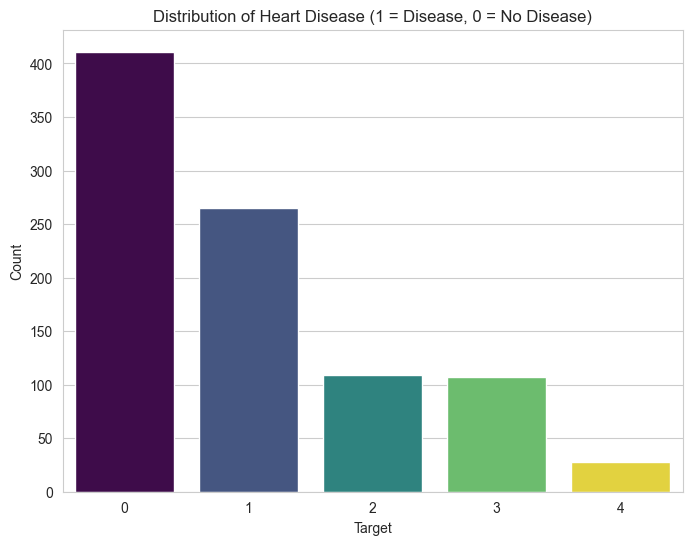

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df, palette='viridis', hue='num', legend=False)
plt.title('Distribution of Heart Disease (1 = Disease, 0 = No Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

**洞察：**该数据集相当均衡，心脏病患者人数略多。这很好，因为这意味着我们的模型将有数量相近的样本可供学习，准确率将成为一个有意义的指标。

#### 2.2 分析特征与目标

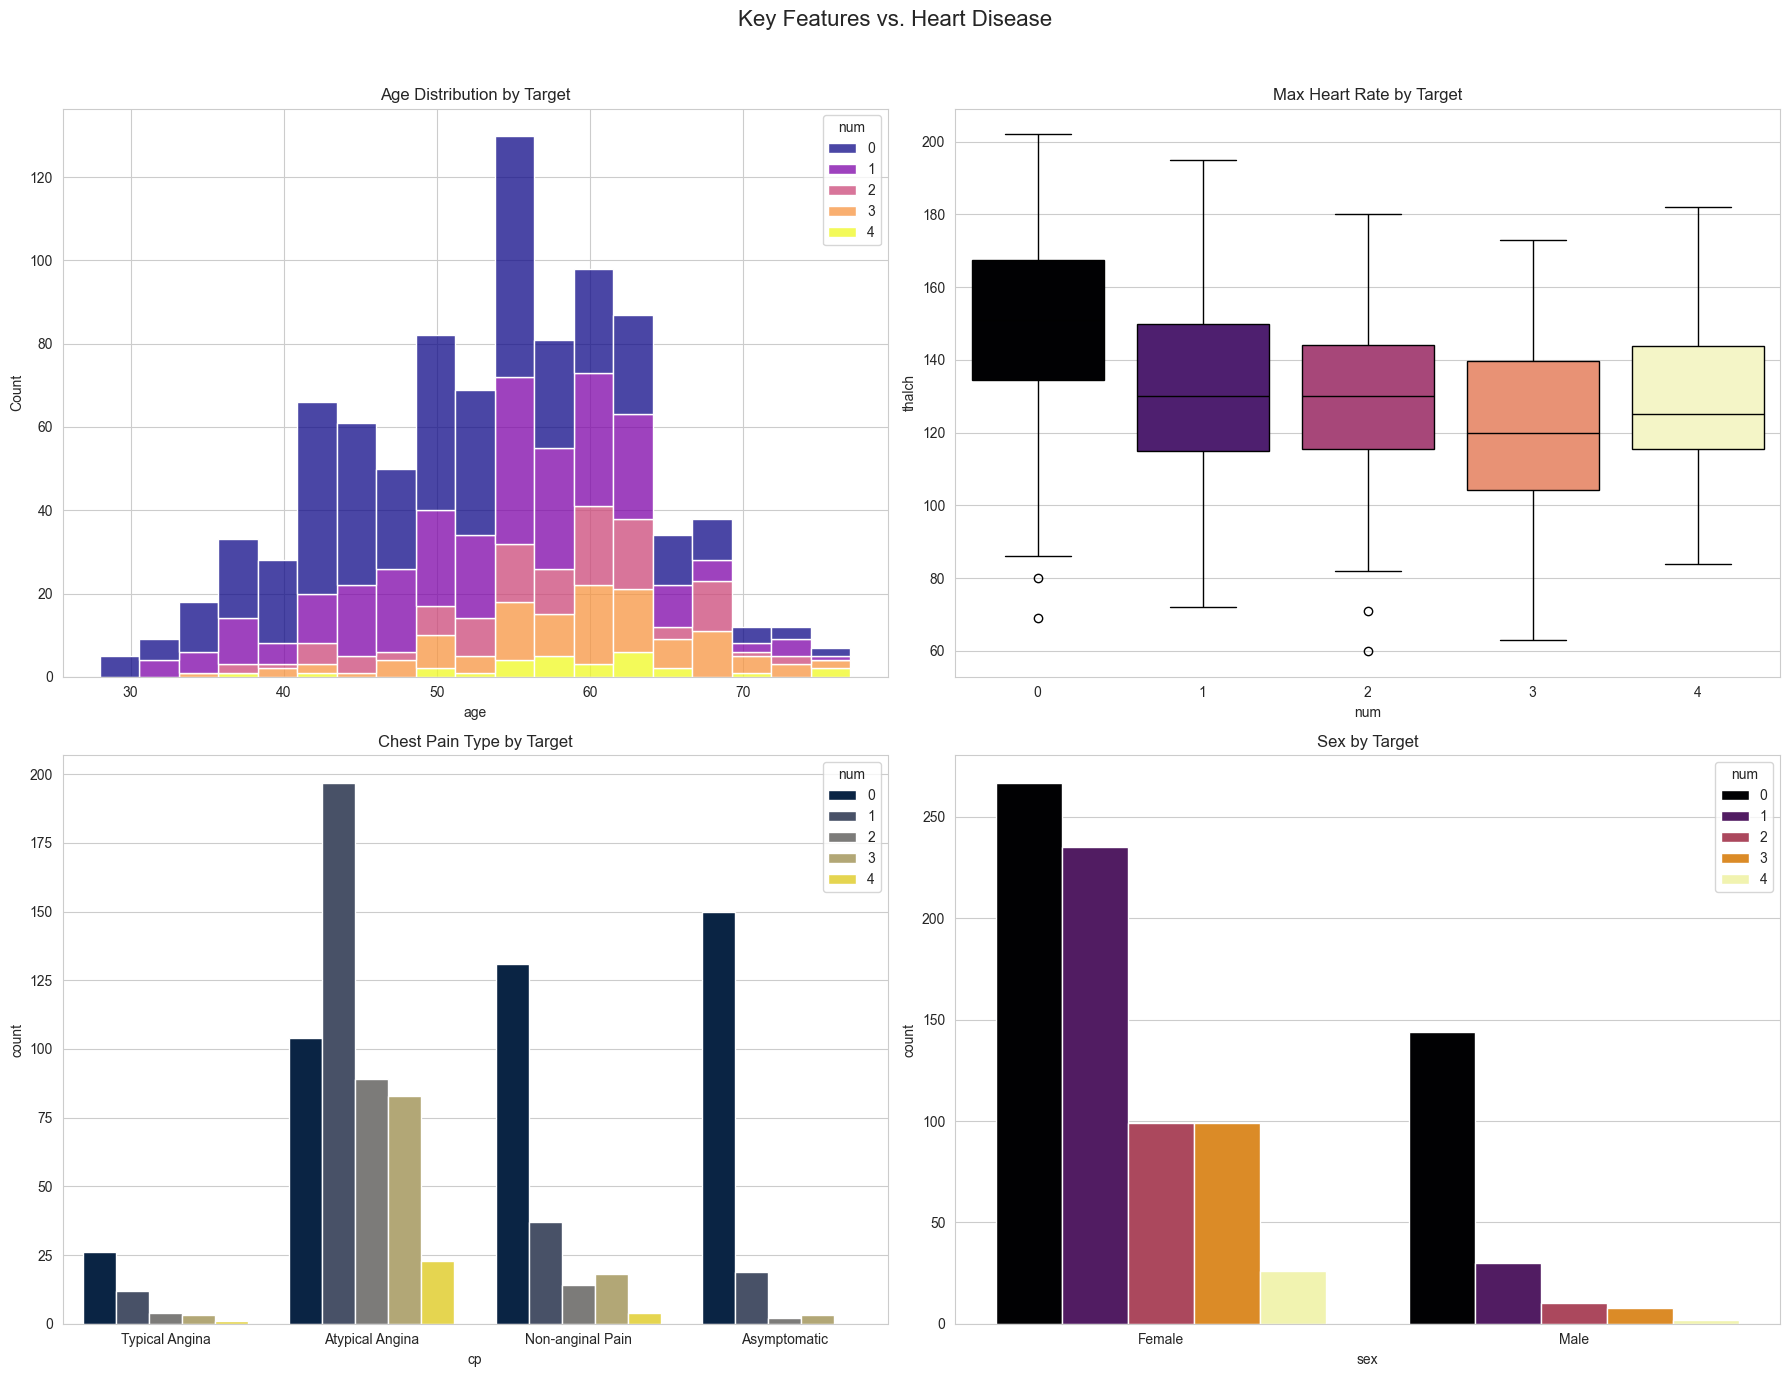

In [21]:
# Let's visualize the relationship between key features and the target
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Key Features vs. Heart Disease', fontsize=16)

# Age vs. Target
sns.histplot(ax=axes[0, 0], data=df, x='age', hue='num', multiple='stack', palette='plasma').set_title('Age Distribution by Target')

# Max Heart Rate vs. Target
sns.boxplot(ax=axes[0, 1], data=df, x='num', y='thalch', palette='magma', hue='num', legend=False).set_title('Max Heart Rate by Target')

# Chest Pain Type vs. Target
cp_plot = sns.countplot(ax=axes[1, 0], data=df, x='cp', hue='num', palette='cividis')
cp_plot.set_title('Chest Pain Type by Target')
cp_plot.set_xticks(range(len(df['cp'].unique())))
cp_plot.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'])

# Sex vs. Target
sex_plot = sns.countplot(ax=axes[1, 1], data=df, x='sex', hue='num', palette='inferno')
sex_plot.set_title('Sex by Target')
sex_plot.set_xticks(range(len(df['sex'].unique())))
sex_plot.set_xticklabels(['Female', 'Male'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**研究发现：**

- **最大心率（`thalach`）：**心脏病患者的最大心率往往较低。

- **胸痛（`cp`）：**1 型和 2 型胸痛（非典型性和非心绞痛性）患者更易患心脏病。令人惊讶的是，0 型胸痛（典型心绞痛）患者患病的可能性较低，而无症状胸痛（3 型）患者患病的可能性则非常高。

- **性别：**与男性相比，该数据集中的女性心脏病患者比例更高。

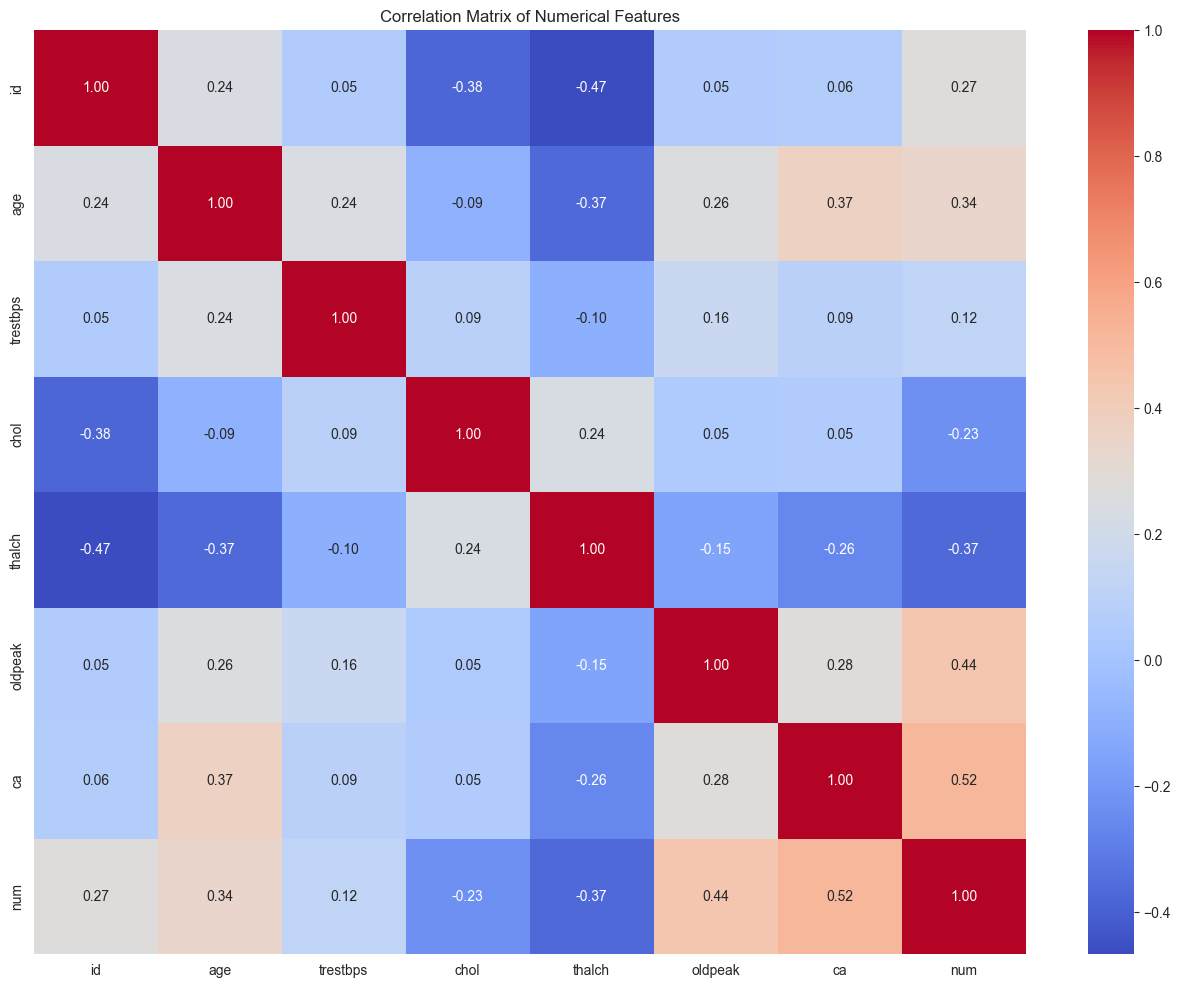

In [22]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 步骤 3：数据预处理

即使数据已经清洗干净，我们仍然需要对其进行预处理，以便用于模型。这包括：

1. **分离特征 (X) 和目标变量 (y)。**

2. **识别需要编码的类别特征。**

3. **对类别特征进行独热编码 (One-Hot Encoding)**，将其转换为数值格式。

4. **缩放数值特征。** 使它们处于相似的尺度。

## **理论概念：Scikit-Learn Pipelines**

Scikit-Learn 中的 **Pipeline** 是一种自动化机器学习工作流程的方法。它允许您将多个步骤（例如预处理、降维和模型训练）串联到一个对象中。

**为什么要使用 Pipelines？**

1. **便捷性：** 简化代码，使工作流程更易于管理。

2. **防止数据泄露：** 确保从训练数据中学习到的数据预处理步骤仅应用于训练数据，并且相同的转换在划分*之后*应用于测试数据。这可以防止测试集中的信息“泄露”到训练过程中。

3. **代码更简洁：** 以逻辑方式组织步骤，使代码更易读、更易于维护。

4. **简化超参数调优：** 借助交叉验证等技术，可以更轻松地对流程中所有步骤的超参数进行调优。

在这个项目中，我们将使用一个流程将预处理步骤（插补、缩放和独热编码）与分类模型结合起来。

In [23]:
from sklearn.impute import SimpleImputer

# Define features (X) and target (y)
X = df.drop('num', axis=1)
y = df['num']

# Drop the 'id' and 'dataset' columns as they are not features
X = X.drop(['id', 'dataset'], axis=1)


# Identify categorical and numerical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Added imputation for categorical features
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

* 创建数值预处理流程：创建一个用于处理数值特征的流程。该流程首先使用策略为“mean”的 SimpleImputer 函数，用列的均值填充缺失的数值值，然后使用 StandardScaler 函数将数值特征缩放至均值为零、方差为 1。

* 创建类别预处理流程：创建一个用于处理类别特征的流程。该流程首先使用策略为“most_frequent”的 SimpleImputer 函数，用出现频率最高的值填充缺失的类别值，然后应用 OneHotEncoder 将类别变量转换为数值格式。使用 `drop='first'` 可以避免多重共线性，而 `handle_unknown='ignore'` 则允许模型在测试期间处理未见过的类别。

### 第四步：模型构建与训练

我们将构建两个模型，并将它们封装在一个 Scikit-Learn Pipeline 中。该 Pipeline 会在训练模型之前自动对数据应用预处理步骤。

#### **理论概念：分类模型**

让我们更详细地了解一下我们使用的分类模型：

* **逻辑回归：**

逻辑回归是一种**线性分类算法**，用于解决二元分类问题（尽管它也可以扩展到多分类）。尽管名称中带有“回归”二字，但它本质上是一种分类方法。它的工作原理是使用**sigmoid（或逻辑）函数**将线性方程 (`wTx + b`) 的输出映射到 0 到 1 之间的概率值。该概率值表示给定数据点属于特定类别（例如，正类）的可能性。然后，将阈值（通常为 0.5）应用于这些概率值，以确定类别标签。该模型学习定义线性决策边界以区分不同类别的最优权重 (`w`) 和偏差 (`b`)。

* **随机森林：**

随机森林是一种**集成学习方法**，属于基于树的模型。它在训练过程中构建大量的**决策树**。每棵树都基于训练数据的**随机子集**（自举法）进行训练，并且在每个分割点仅考虑**随机子集**的特征。对于分类任务，最终预测结果由所有树的预测结果进行**多数投票**得出。这种构建树的随机性有助于降低**方差**并防止**过拟合**，从而使随机森林比单个决策树更稳健，性能通常也更高。

* **支持向量机 (SVM)：**

支持向量机是一种强大的算法，可用于线性分类和非线性分类。SVM 的基本思想是在高维空间中找到一个**最优超平面**，将不同类别的数据点分隔开来。 “最优”超平面是指不同类别中距离最近的数据点（称为**支持向量**）之间间隔最大的超平面。对于非线性可分数据，支持向量机 (SVM) 使用**核技巧**将数据隐式映射到更高维度的特征空间，从而实现线性分离。常用的核函数包括线性核、多项式核和径向基函数 (RBF) 核。

* **K近邻 (KNN)：**

K近邻算法是一种简单直观的**基于实例的**或**惰性学习**算法。它在训练阶段不从训练数据中学习判别函数，而是记忆训练数据集。为了对新的、未见过的数据点进行分类，它计算该新点与训练数据集中所有点之间的**距离**（例如，欧氏距离）。然后，它会识别出**k个最近的数据点**。新数据点的类别标签由这k个最近邻数据点中占多数的类别决定。k值和距离度量的选择是重要的超参数，会显著影响性能。

#### 4.1 Model 1: Logistic Regression (Baseline)

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 正确识别数值/类别列（兼容 object + string）
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # 更鲁棒
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)


Numerical features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


#### 4.2 Model 2: Random Forest Classifier (Advanced)

In [26]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

#### 4.3 Model 3: Support Vector Machine (SVM)

In [28]:
from sklearn.svm import SVC

# Create the SVM pipeline
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', SVC(random_state=42))])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

#### 4.4 Model 4: K-Nearest Neighbors (KNN)

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN pipeline
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', KNeighborsClassifier())])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)

### Step 5: Model Evaluation

#### **理论概念：混淆矩阵和关键指标**

对于分类任务而言，准确率并非衡量性能的唯一标准。我们使用**混淆矩阵**来更深入地了解模型的性能。

- **真阳性 (TP)：** 正确预测为阳性类别（模型判定为“患病”，患者确实患病）。

- **真阴性 (TN)：** 正确预测为阴性类别（模型判定为“未患病”，患者确实未患病）。

- **假阳性 (FP)：** 错误预测为阳性类别（模型判定为“患病”，但患者实际上未患病）。也称为**I 类错误**。

- **假阴性 (FN)：** 错误预测为阴性类别（模型判定为“未患病”，但患者确实患病）。也称为**II 类错误**。这通常是医疗诊断中最危险的错误类型。

由此，我们得出以下关键指标：

- **准确率：** (真阳性 + 真阴性) / 总分。总体而言，分类器的正确率是多少？

- **精确率：** 真阳性 / (真阳性 + 假阳性)。在所有被模型*预测*患有该疾病的患者中，实际患病的患者有多少？（衡量假阳性造成的损失）。

- **召回率（灵敏度）：** 真阳性 / (真阳性 + 假阴性)。在所有*实际*患有该疾病的患者中，模型正确识别出的患者有多少？（衡量假阴性造成的损失）。

- **F1 分数：** 精确率和召回率的调和平均值。当精确率和召回率之间存在权衡时，F1 分数是评估模型整体性能的绝佳单一指标。

In [31]:
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\n--- Support Vector Machine (SVM) Performance ---")
print(classification_report(y_test, y_pred_svm, zero_division=0))

print("\n--- K-Nearest Neighbors (KNN) Performance ---")
print(classification_report(y_test, y_pred_knn, zero_division=0))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        82
           1       0.46      0.53      0.49        53
           2       0.30      0.14      0.19        22
           3       0.19      0.19      0.19        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.34      0.34      0.33       184
weighted avg       0.53      0.57      0.54       184


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        82
           1       0.53      0.53      0.53        53
           2       0.12      0.09      0.10        22
           3       0.10      0.10      0.10        21
           4       0.00      0.00      0.00         6

    accuracy                           0.56       184
   macro avg       0.30      0.32      0.31       184
we

### 第七步：结论

本项目构建了用于预测心脏病的分类模型。

**关键步骤：**

1. **确定分类目标：**预测二元结果（患病或未患病）。

2. **进行全面的探索性数据分析：**识别出与目标密切相关的关键医学指标，例如胸痛类型、最大心率和“ca”。

3. **构建稳健的预处理流程：**使用“ColumnTransformer”和“Pipeline”系统地处理类别特征和数值特征。

4. **训练并比较四个模型：**评估了逻辑回归、随机森林、支持向量机 (SVM) 和 K 近邻 (KNN)。评估结果表明，支持向量机 (SVM) 的性能略优于其他模型。

5. **使用合适的指标评估模型：** 使用混淆矩阵、精确率和召回率来了解模型在医疗环境中的性能，在医疗环境中，最大限度地减少假阴性至关重要。

6. **解读模型结果：** 使用特征重要性（以随机森林模型为例）来确认一些最具预测性的医疗因素，从而提供可操作的见解。

这个端到端的工作流程展示了分类在真实医疗场景中的应用，从原始数据到预测模型及其评估。

**评估结果：**支持向量机 (SVM) 分类器的性能略优于其他模型，总体准确率达到 0.59。虽然所有模型在处理低频类别（2、3 和 4）时表现不佳，但 SVM 在预测类别 1（心脏病）时 F1 分数略高。提供的混淆矩阵是随机森林模型的，该模型在类别 0 和类别 1 上表现良好，但在处理低频类别时也表现不佳。根据分类报告，在本次评估的四个模型中，SVM 的性能最佳。

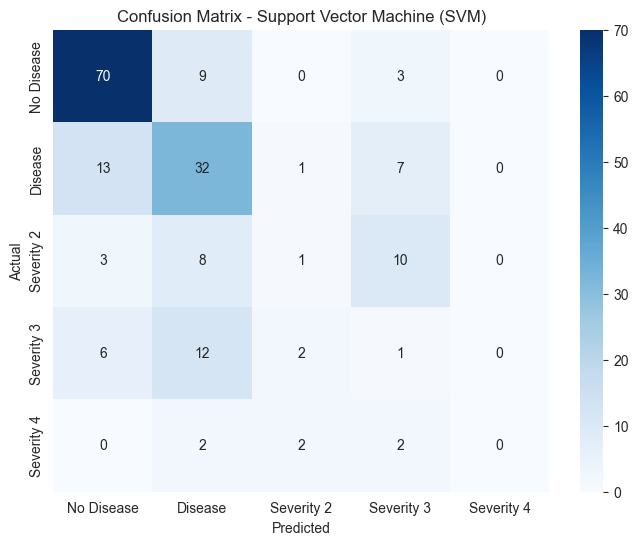

In [32]:
# Visualize the confusion matrix for the best model (SVM)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease', 'Severity 2', 'Severity 3', 'Severity 4'], yticklabels=['No Disease', 'Disease', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Support Vector Machine (SVM)')
plt.show()

**评估结果：**随机森林分类器表现卓越，各项指标均接近完美（准确率、精确率、召回率和 F1 分数均在 99% 至 100% 之间）。其性能显著优于逻辑回归模型。混淆矩阵显示，该模型在测试集上仅出现一个错误。

### 第六步：特征重要性

像随机森林这样的基于树的模型的一个主要优势是，我们可以轻松地看出哪些特征对预测结果的影响最大。

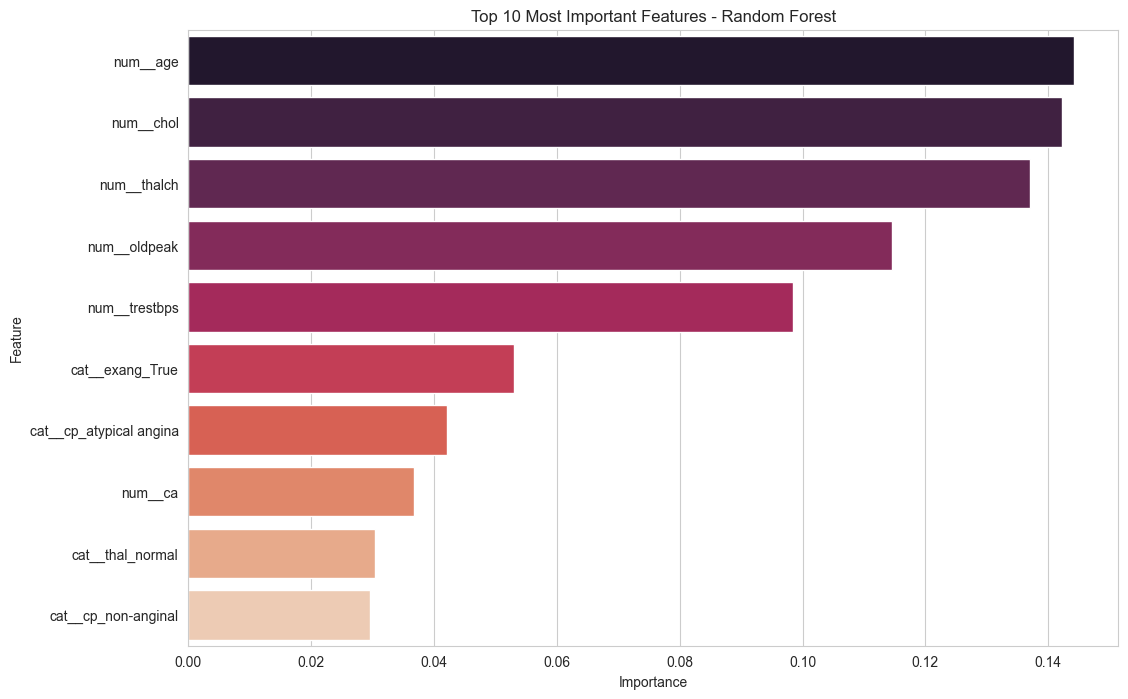

In [33]:
# Extract feature names after one-hot encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances from the trained model
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='rocket', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features - Random Forest')
plt.show()

**洞察：**模型发现，`ca`（荧光显影显示的主要血管数量）、`thalach`（最大心率）、`thal`（地中海贫血类型）和`cp`（胸痛类型）是最重要的预测因子。这与我们的探索性数据分析和医学直觉相符，证实了这些因素对于诊断心脏病至关重要。

### 第七步：结论

本项目构建了一个高精度的心脏病预测分类模型。

**关键步骤：**

1. **确定分类目标：** 预测二元结果（患病或未患病）。

2. **进行全面的探索性数据分析 (EDA)：** 识别出与目标密切相关的关键医学指标，例如胸痛类型、最大心率和“ca”。

3. **构建稳健的预处理流程：** 使用 `ColumnTransformer` 和 `Pipeline` 系统地处理类别特征和数值特征。

4. **训练并比较两个模型：** 结果表明，随机森林分类器（准确率 99%）远优于逻辑回归基线模型（准确率 86%）。

5. **使用合适的指标评估模型：** 使用混淆矩阵、精确率和召回率来了解模型在医学环境中的性能，在医学环境中，最大限度地减少假阴性至关重要。

6. **模型结果解读：**运用特征重要性分析，确定最具预测性的医学因素，从而提供可操作的见解。

这一端到端的工作流程展示了分类在真实医疗场景中的强大功能，实现了从原始数据到高度准确且易于解读的预测模型的转化。

### 提交标准

为满足本项目提交要求，请确保以下几点：

1. **完成探索性数据分析 (EDA)：** 执行分析数据集所需的所有步骤，包括可视化和摘要，以了解数据特征和关系。

2. **不使用 Pipeline 进行模型训练：** 直接训练至少一个分类模型，不使用 Scikit-Learn 的 `Pipeline` 对象进行预处理和模型链式构建。这意味着在训练模型之前，需要手动对数据应用预处理步骤（例如插补和缩放/编码）。

3. **提交完整的 Jupyter Notebook：** 确保最终提交的内容包含完整的 Colab Notebook，所有代码单元格均已执行，且输出结果可见。

满足这些标准将证明您对机器学习工作流程中各个步骤的理解。